Pomyślnie wczytano publiczną bazę danych (Olivetti/AT&T).
Dane: 400 obrazów o wymiarach 64x64.
Obraz testowy: Osoba ID 23, Zdjęcie nr 1 (Indeks w macierzy: 18)
Minimalna liczba 'eigenfaces' (r): 123
Zachowany procent informacji z r=123: 95.04%


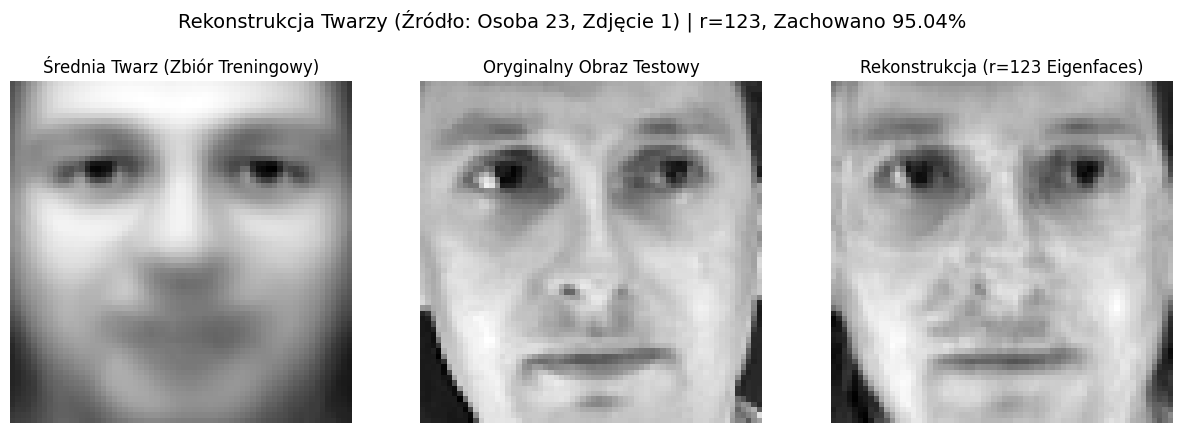

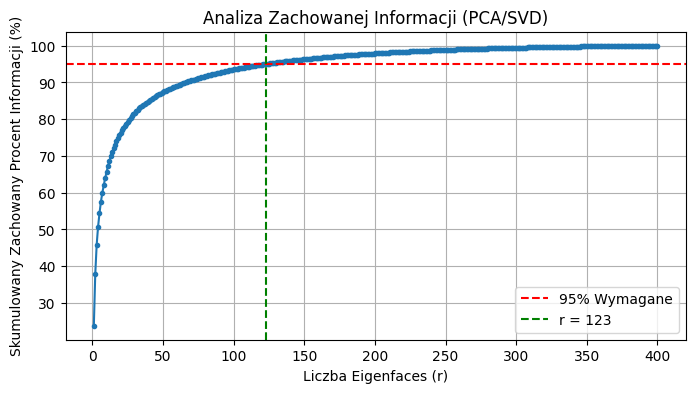

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from sklearn.datasets import fetch_olivetti_faces 
import random

K_PERCENT = 95.0

# Wczytanie bazy danych Olivetti (składa się z 400 obrazów 64x64)
try:
    # Wczytanie z targetami (numery osób)
    data = fetch_olivetti_faces(shuffle=True, random_state=42)
    
    images_flat = data.data 
    m, d = images_flat.shape 
    image_height = data.images.shape[1]
    image_width = data.images.shape[2] 
    
    # A - macierz Piksele x Liczba Obrazów
    A = images_flat.T 
    
    # NUMERY OSÓB (0-39) odpowiadające kolumnom w A
    person_labels = data.target 

    print(f"Pomyślnie wczytano publiczną bazę danych (Olivetti/AT&T).")
    print(f"Dane: {m} obrazów o wymiarach {image_height}x{image_width}.")
    
except Exception as e:
    print(f"Błąd wczytywania bazy danych: {e}")
    d, m = 10000, 50 
    A = np.random.rand(d, m) * 255
    image_height, image_width = 100, 100
    person_labels = np.zeros(m)

# Obliczanie "Średniej Twarzy"
mean_face = np.mean(A, axis=1)

# Odjęcie "Średniej Twarzy" od każdego obrazu
X = A - mean_face[:, np.newaxis] 

# Wybór obrazu testowego i określenie źródła
test_index = random.randint(0, m - 1)
x_test = A[:, test_index]
x_test_mean_subtracted = x_test - mean_face

# OKREŚLENIE ŹRÓDŁA OBRAZU TESTOWEGO 
person_id = person_labels[test_index] 
# Olivetti ma 10 zdjęć na osobę. Obliczamy numer zdjęcia dla danej osoby.
image_num_for_person = np.sum(person_labels[:test_index] == person_id) + 1 

# SVD, Analiza i Znalezienie min 
U, S, Vh = svd(X, full_matrices=False)
singular_values_sq = S**2
total_variance = np.sum(singular_values_sq)
cumulative_percentage = (np.cumsum(singular_values_sq) / total_variance) * 100

r_index = np.where(cumulative_percentage > K_PERCENT)[0]
r_min = r_index[0] + 1 if r_index.size > 0 else len(S)
zachowany_procent = cumulative_percentage[r_min - 1]

print(f"Obraz testowy: Osoba ID {person_id}, Zdjęcie nr {image_num_for_person} (Indeks w macierzy: {test_index})")
print(f"Minimalna liczba 'eigenfaces' (r): {r_min}")
print(f"Zachowany procent informacji z r={r_min}: {zachowany_procent:.2f}%")

# Rekonstrukcja Obrazu Testowego
U_tilde = U[:, :r_min]
x_test_approx_mean_subtracted = U_tilde @ (U_tilde.T @ x_test_mean_subtracted)
x_test_approx = x_test_approx_mean_subtracted + mean_face


# Wizualizacja Wyników z Źródłem

image_orig_reshaped = x_test.reshape(image_height, image_width)
image_approx_reshaped = x_test_approx.reshape(image_height, image_width)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Rekonstrukcja Twarzy (Źródło: Osoba {person_id}, Zdjęcie {image_num_for_person}) | r={r_min}, Zachowano {zachowany_procent:.2f}%", 
    fontsize=14
)

# Średnia Twarz
axes[0].imshow(mean_face.reshape(image_height, image_width), cmap='gray')
axes[0].set_title('Średnia Twarz (Zbiór Treningowy)')
axes[0].axis('off')

# Oryginalny Obraz Testowy
axes[1].imshow(image_orig_reshaped, cmap='gray')
axes[1].set_title(f'Oryginalny Obraz Testowy')
axes[1].axis('off')

# Zrekonstruowany Obraz
axes[2].imshow(image_approx_reshaped, cmap='gray')
axes[2].set_title(f'Rekonstrukcja (r={r_min} Eigenfaces)')
axes[2].axis('off')

plt.show()

# Wykres skumulowanej wariancji
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_percentage) + 1), cumulative_percentage, marker='.', linestyle='-')
plt.axhline(y=K_PERCENT, color='r', linestyle='--', label=f'{K_PERCENT:.0f}% Wymagane')
plt.axvline(x=r_min, color='g', linestyle='--', label=f'r = {r_min}')
plt.xlabel('Liczba Eigenfaces (r)')
plt.ylabel('Skumulowany Zachowany Procent Informacji (%)')
plt.title('Analiza Zachowanej Informacji (PCA/SVD)')
plt.legend()
plt.grid(True)
plt.show()